In [24]:
import glob
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr = 0.001

inputs = glob.glob("src/old_obs*pt")
outputs = glob.glob("src/new_obs*pt")
actions  = glob.glob("src/action*pt")

inputs.sort(key=lambda x:int(x.split("_")[-1].split(".")[0]))
outputs.sort(key=lambda x:int(x.split("_")[-1].split(".")[0]))
actions.sort(key=lambda x:int(x.split("_")[-1].split(".")[0]))

assert len(inputs) == len(outputs) == len(actions)


# inputs = inputs[:200]
# outputs = outputs[:200]
# actions = actions[:200]

def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

In [25]:
from torch import nn
from torch.nn import functional as F
import numpy as np

# define the NN architecture
class AutoencoderWithUncertainty(nn.Module):
    def __init__(self):
        super(AutoencoderWithUncertainty, self).__init__()
        self.conv1 = nn.Conv2d(4, 16, (2, 2))
        self.conv2 = nn.Conv2d(16, 32, (2, 2))
        self.conv3 = nn.Conv2d(32, 64, (2, 2))
        self.mu_conv1 = nn.ConvTranspose2d(64, 32, (3, 3))
        self.mu_conv2 = nn.ConvTranspose2d(32, 16, (3, 3))
        self.mu_conv3 = nn.ConvTranspose2d(16, 3, (3, 3))
        self.sigma_1 = nn.Linear(64, 128)
        self.sigma_2 = nn.Linear(128, 128)
        self.sigma_3 = nn.Linear(128, 147)
        self.linear_mu_out = nn.Linear(147 * 2 + (7 * 7), 147)
        self.linear_sigma_out = nn.Linear(147 * 2 + (7 * 7), 147)

#         torch.nn.init.constant(self.image_deconv_sigma[0].weight, -2)
#         torch.nn.init.constant(self.image_deconv_sigma[2].weight, -2)
#         torch.nn.init.constant(self.image_deconv_sigma[4].weight, -2)
        

    def forward(self, x, action_channel):
        batch_size, _, _, channels = x.shape
        an_input = torch.cat([x, action_channel], dim=3)
        an_input = an_input.reshape((batch_size, channels + 1, 7, 7))
        x1 = F.relu(self.conv1(an_input))
        x1 = F.max_pool2d(x1, (2, 2))
        x2 = F.relu(self.conv2(x1))
        x3 = F.relu(self.conv3(x2))
        mu1 = F.relu(self.mu_conv1(x3))
        mu2 = F.relu(self.mu_conv2(mu1))
        mu3 = (self.mu_conv3(mu2))
        mu3 = torch.flatten(mu3, start_dim=1)
        an_input = torch.flatten(an_input,start_dim=1)
        mu = torch.cat((mu3, an_input), dim=1)
        mu = self.linear_mu_out(mu)
        x3 = x3.reshape(batch_size, -1)
        sigma1 = F.relu(self.sigma_1(x3))
        sigma2 = F.relu(self.sigma_2(sigma1))
        sigma = (self.sigma_3(sigma2))
        sigma = torch.cat((sigma, an_input), dim=1)
        sigma = self.linear_sigma_out(sigma)
        sigma = sigma.reshape(batch_size, 7, 7, 3)
        mu = mu.reshape(batch_size, 7, 7, 3)
        return mu, sigma


# MSE#

In [26]:
# model = AutoencoderWithUncertainty().to(device)
# opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0)

# rewards_mse = []

# for i in range(len(inputs)):
#     opt.zero_grad()
#     old_obs = torch.load(inputs[i]).to(device)
#     action = torch.load(actions[i]).to(device)
#     new_obs = torch.load(outputs[i]).to(device)
#     action_channel = torch.stack([(torch.ones((7, 7, 1)) * an_action)/6 for an_action in action]).to(device)
#     mu, sigma = model(old_obs, action_channel)
#     mse = F.mse_loss(mu, new_obs, reduction="none")
#     loss = torch.sum(torch.mean(mse, dim=(1, 2, 3)))  
#     loss.backward()
#     opt.step()
#     rewards_mse.append(torch.sum(torch.mean(mse, dim=(1,2,3))))

# AMA #

In [27]:
model = AutoencoderWithUncertainty().to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0)

rewards_ama_goal = []

for i in range(len(inputs)):
    opt.zero_grad()
    old_obs = torch.load(inputs[i]).to(device)
    action = torch.load(actions[i]).to(device)
    new_obs = torch.load(outputs[i]).to(device)
    action_channel = torch.stack([(torch.ones((7, 7, 1)) * an_action)/6 for an_action in action]).to(device)
    mu, sigma = model(old_obs, action_channel)
    mse = F.mse_loss(mu, new_obs, reduction="none")
    loss = torch.sum(torch.mean((torch.exp(-sigma) * mse) + 0.1 * sigma, dim=(1, 2, 3)))  
    loss.backward()
    opt.step()
    rewards_ama_goal.append(torch.sum(torch.mean(torch.clamp(mse - torch.exp(sigma), 0), dim=(1,2,3))))
    #rewards_ama.append(torch.sum(torch.mean(mse, dim=(1,2,3))))

In [28]:
model = AutoencoderWithUncertainty().to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0)

rewards_ama = []

for i in range(len(inputs)):
    opt.zero_grad()
    old_obs = torch.load(inputs[i]).to(device)
    action = torch.load(actions[i]).to(device)
    new_obs = torch.load(outputs[i]).to(device)
    action_channel = torch.stack([(torch.ones((7, 7, 1)) * an_action)/6 for an_action in action]).to(device)
    mu, sigma = model(old_obs, action_channel)
    mse = F.mse_loss(mu, new_obs, reduction="none")
    loss = torch.sum(torch.mean((torch.exp(-sigma) * mse) + sigma, dim=(1, 2, 3)))  
    loss.backward()
    opt.step()
    rewards_ama.append(torch.sum(torch.mean((mse - torch.exp(sigma)), dim=(1,2,3))))
    #rewards_ama.append(torch.sum(torch.mean(mse, dim=(1,2,3))))

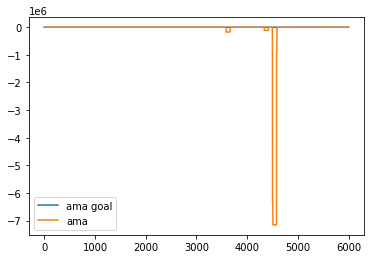

In [29]:
plt.plot(smooth([i for i in rewards_ama_goal], 80), label="ama goal")
plt.plot(smooth([i for i in rewards_ama], 80), label="ama")

plt.legend()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


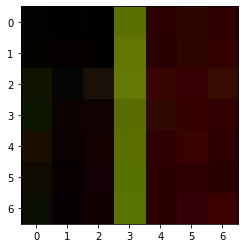

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


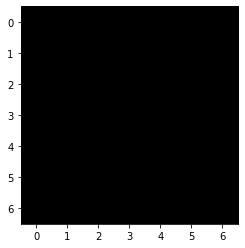

true


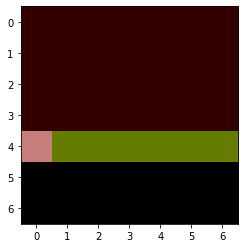

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


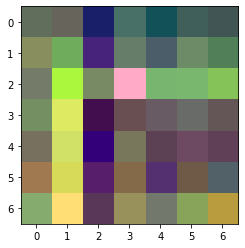

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


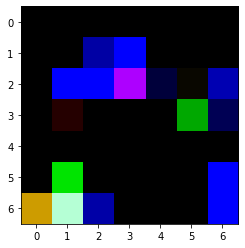

true


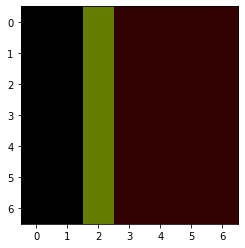

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


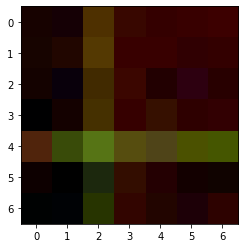

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


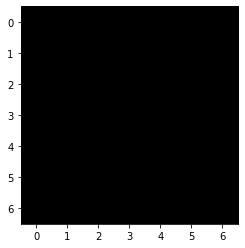

true


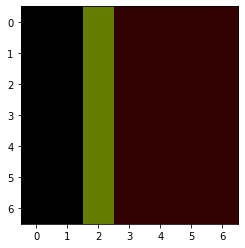

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


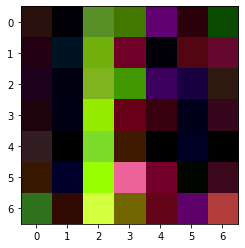

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


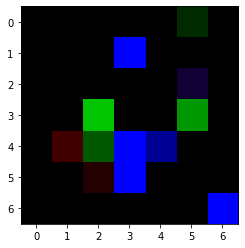

true


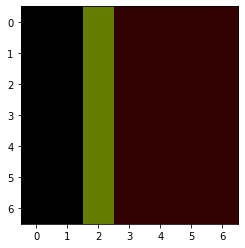

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


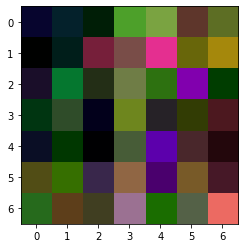

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


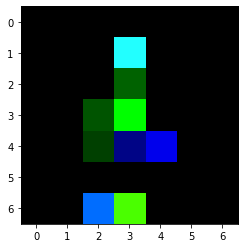

true


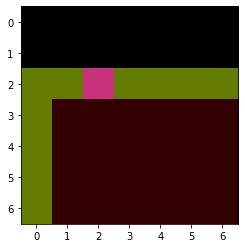

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


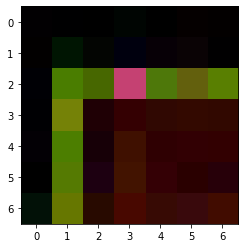

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


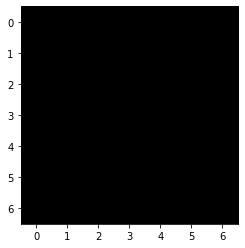

true


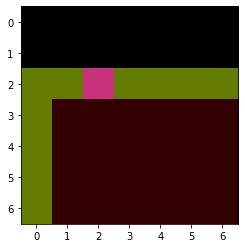

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


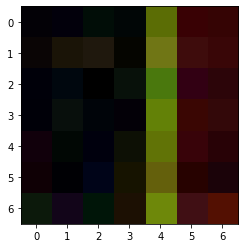

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


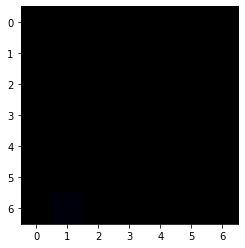

true


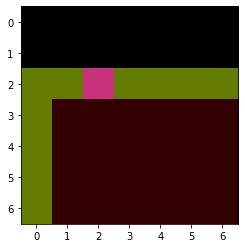

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


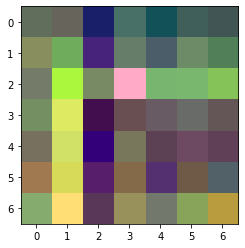

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


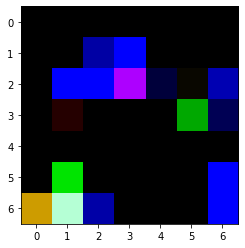

true


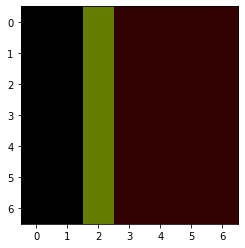

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


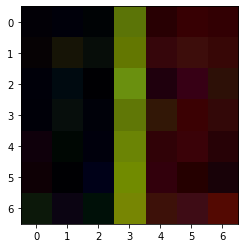

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


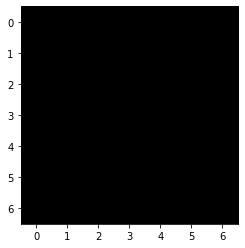

true


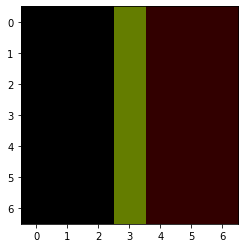

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


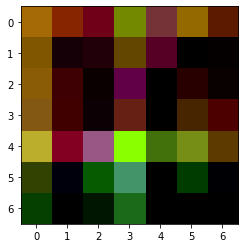

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


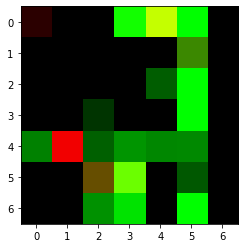

true


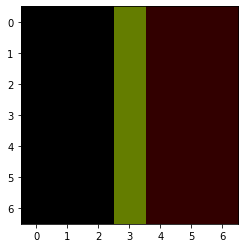

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


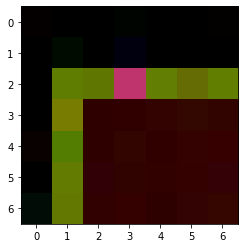

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


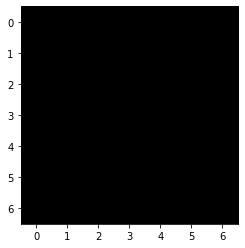

true


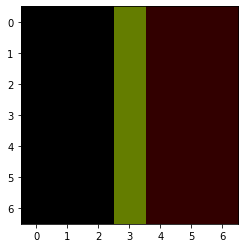

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


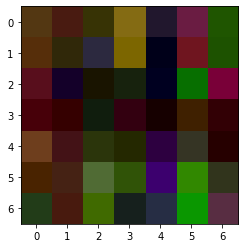

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


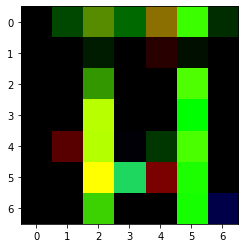

true


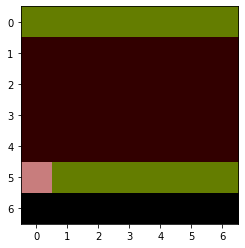

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


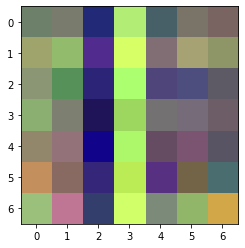

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


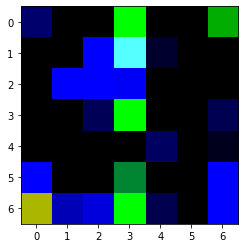

true


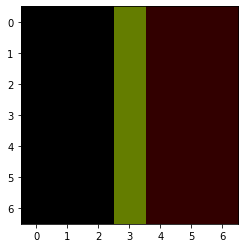

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


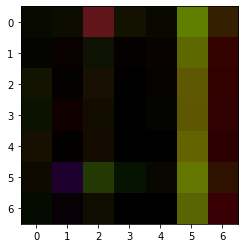

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


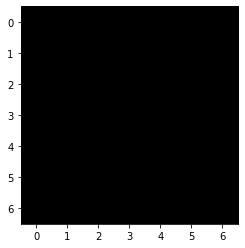

true


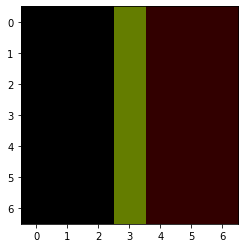

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


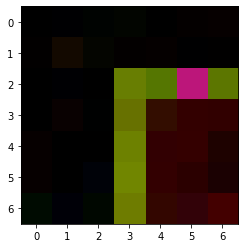

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


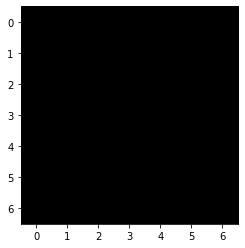

true


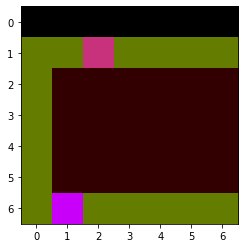

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


mu


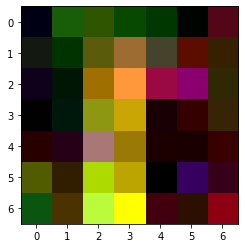

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


sigma


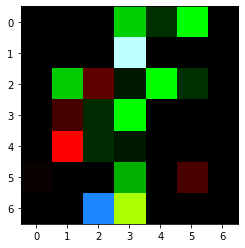

true


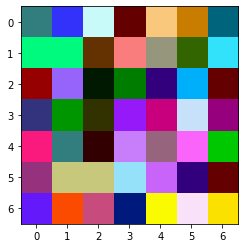

mu


IndexError: index 16 is out of bounds for dimension 0 with size 16

In [30]:
i = 0
for i in range(100):
    old_obs = torch.load(inputs[i]).to(device)
    action = torch.load(actions[i]).to(device)
    new_obs = torch.load(outputs[i]).to(device)
    action_channel = torch.stack([(torch.ones((7, 7, 1)) * an_action)/6 for an_action in action]).to(device)
    pred = model(old_obs, action_channel)
    print("mu")
    plt.imshow(pred[0][i].detach().cpu().numpy())
    plt.show()
    print("sigma")
    plt.imshow(pred[1][i].detach().cpu().numpy())
    plt.show()
    print("true")
    plt.imshow(new_obs[0].detach().cpu().numpy())
    plt.show()
    plt.close()